# JEPA Writeup 7/27: experiments and health


In [1]:
from pathlib import Path
import gc
import io
import os
import subprocess

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd

from cody_jepa.single_stream_jepa import load_checkpoint


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'outputs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the cody-jepa repository root')


REPO_ROOT = find_repo_root()
OUTPUT_DIR = Path(os.environ.get(
    'CODY_JEPA_REPRO_OUTPUT_DIR',
    REPO_ROOT / 'results' / 'generated' / 'writeup-7-27-health',
)).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STAGE_A_RUNS = [
    ('a00-baseline', 'a00 baseline'),
    ('a01-lr3e-5', 'a01 lr 3e-5'),
    ('a02-lr3e-4', 'a02 lr 3e-4'),
    ('a03-ema0.995', 'a03 EMA 0.995'),
    ('a04-mask-light', 'a04 light mask'),
    ('a05-mask-heavy', 'a05 heavy mask'),
    ('a06-pred-depth3', 'a06 predictor depth 3'),
    ('a07-clip-var', 'a07 clip variance'),
]
CHECKPOINTS = {
    run_id: REPO_ROOT / 'outputs' / 'phase1' / run_id / 'latest.pt'
    for run_id, _ in STAGE_A_RUNS
}
missing = [path for path in CHECKPOINTS.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(f'Missing Stage A checkpoints: {missing}')

print(f'Repository: {REPO_ROOT}')
print(f'Generated artifacts: {OUTPUT_DIR}')


Repository: /Users/theodoremui/dev/cody-jepa
Generated artifacts: /Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-health


## Experiment contract

The prose questions are editorial metadata. The parameter changes are validated against the stored checkpoint configuration and mask definitions.


In [2]:
experiment_rows = [
    ('a00-baseline', 'a00', 'none (control)', 'Does the control reproduce the failure?'),
    ('a01-lr3e-5', 'a01', 'learning rate 1e-4 to 3e-5', 'Is optimization too aggressive?'),
    ('a02-lr3e-4', 'a02', 'learning rate 1e-4 to 3e-4', 'Can stronger optimization force context use?'),
    ('a03-ema0.995', 'a03', 'EMA constant 0.99 to 0.995', 'Does a slower target help?'),
    ('a04-mask-light', 'a04', 'light masks (more context)', 'Does more visible context help?'),
    ('a05-mask-heavy', 'a05', 'heavy masks (less context)', 'Does a harder task help?'),
    ('a06-pred-depth3', 'a06', 'predictor depth 6 to 3', "Is the predictor absorbing the encoder's work?"),
    ('a07-clip-var', 'a07', 'variance penalty on pooled clips', 'Does fixing the pooling mismatch work?'),
]
experiment_table = pd.DataFrame(
    [{'run_id': run_id, 'Run': short, 'One change': change, 'Question it answers': question}
     for run_id, short, change, question in experiment_rows]
)

configs = {}
mask_groups = {}
for run_id, _ in STAGE_A_RUNS:
    checkpoint = load_checkpoint(CHECKPOINTS[run_id])
    configs[run_id] = checkpoint['config']
    mask_groups[run_id] = checkpoint['mask_groups']
    del checkpoint
    gc.collect()

baseline = configs['a00-baseline']
checks = {
    'a00-baseline': baseline['lr'] == 1e-4 and baseline['ema_start'] == 0.99 and baseline['pred_depth'] == 6,
    'a01-lr3e-5': configs['a01-lr3e-5']['lr'] == 3e-5,
    'a02-lr3e-4': configs['a02-lr3e-4']['lr'] == 3e-4,
    'a03-ema0.995': configs['a03-ema0.995']['ema_start'] == 0.995,
    'a04-mask-light': mask_groups['a04-mask-light'][0]['num_blocks'] == 6 and mask_groups['a04-mask-light'][0]['spatial_scale'] == 0.1,
    'a05-mask-heavy': mask_groups['a05-mask-heavy'][0]['num_blocks'] == 10 and mask_groups['a05-mask-heavy'][0]['spatial_scale'] == 0.2,
    'a06-pred-depth3': configs['a06-pred-depth3']['pred_depth'] == 3,
    'a07-clip-var': configs['a07-clip-var']['clip_var_coef'] == 1.0,
}
failed = [run_id for run_id, passed in checks.items() if not passed]
if failed:
    raise AssertionError(f'Experiment descriptions disagree with checkpoint configs: {failed}')
for run_id, _ in STAGE_A_RUNS:
    if configs[run_id]['num_epochs'] != 40 or configs[run_id]['eval_every_epochs'] != 5:
        raise AssertionError(f'{run_id}: not a duration-matched 40-epoch run')

experiment_csv = OUTPUT_DIR / 'writeup-7-27-experiment-table.csv'
experiment_table.drop(columns='run_id').to_csv(experiment_csv, index=False)
print(experiment_table.drop(columns='run_id').to_string(index=False))
print(f'Experiment table: {experiment_csv}')


Run                       One change                            Question it answers
a00                   none (control)        Does the control reproduce the failure?
a01       learning rate 1e-4 to 3e-5                Is optimization too aggressive?
a02       learning rate 1e-4 to 3e-4   Can stronger optimization force context use?
a03       EMA constant 0.99 to 0.995                     Does a slower target help?
a04       light masks (more context)                Does more visible context help?
a05       heavy masks (less context)                       Does a harder task help?
a06           predictor depth 6 to 3 Is the predictor absorbing the encoder's work?
a07 variance penalty on pooled clips         Does fixing the pooling mismatch work?
Experiment table: /Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-health/writeup-7-27-experiment-table.csv


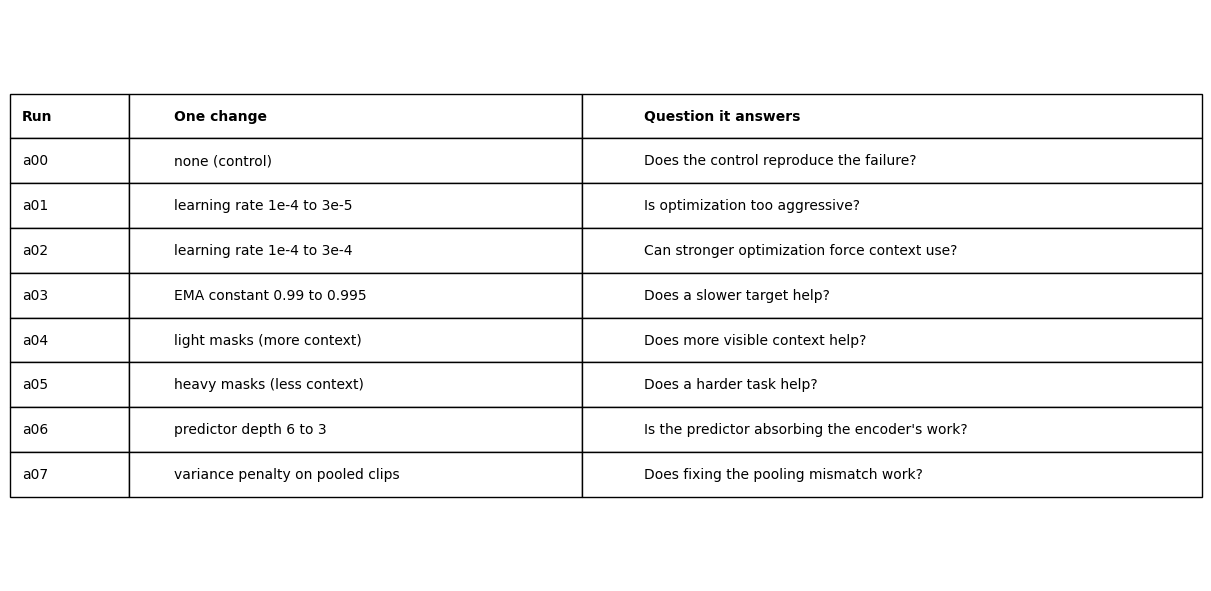

/Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-health/writeup-7-27-experiment-table.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 5.8), constrained_layout=True)
ax.axis('off')
table_artist = ax.table(
    cellText=experiment_table[['Run', 'One change', 'Question it answers']].values,
    colLabels=['Run', 'One change', 'Question it answers'],
    cellLoc='left', colLoc='left', loc='center', colWidths=[0.10, 0.38, 0.52],
)
table_artist.auto_set_font_size(False)
table_artist.set_fontsize(10)
table_artist.scale(1, 2.1)
for (row, _), cell in table_artist.get_celld().items():
    cell.set_edgecolor('black')
    if row == 0:
        cell.set_text_props(weight='bold')
experiment_image = OUTPUT_DIR / 'writeup-7-27-experiment-table.png'
fig.savefig(experiment_image, dpi=180, bbox_inches='tight')
plt.show()
print(experiment_image)


## Load health trajectories


In [4]:
HEALTH_METRICS = {
    'loss': 'JEPA loss',
    'cosine': 'Cosine similarity',
    'effective_rank': 'Online full-view effective rank',
    'subject_balanced_context_shuffle_loss_gap': 'Subject-balanced wrong-context loss gap',
}

health_rows = []
for run_id, label in STAGE_A_RUNS:
    checkpoint = load_checkpoint(CHECKPOINTS[run_id])
    if checkpoint.get('completed_epochs') != 40 or checkpoint.get('global_step') != 1560:
        raise ValueError(f'{run_id}: expected completed epoch 40, step 1560')
    evaluated = [row for row in checkpoint['history'] if row.get('val') is not None]
    if len(evaluated) != 8 or [row['epoch'] for row in evaluated] != list(range(5, 41, 5)):
        raise ValueError(f'{run_id}: expected eight fifth-epoch validation rows')
    for row in evaluated:
        validation = row['val']
        missing = set(HEALTH_METRICS) - set(validation)
        if missing:
            raise ValueError(f'{run_id}: missing metrics {sorted(missing)}')
        health_rows.append({
            'run_id': run_id, 'label': label, 'epoch': int(row['epoch']), 'step': int(row['step']),
            **{metric: float(validation[metric]) for metric in HEALTH_METRICS},
        })
    del checkpoint
    gc.collect()

health = pd.DataFrame(health_rows)
if health.groupby('run_id').size().ne(8).any():
    raise ValueError('Each Stage A run must contribute eight health rows')
if not np.isfinite(health[list(HEALTH_METRICS)].to_numpy()).all():
    raise ValueError('Health trajectories contain non-finite values')
health_csv = OUTPUT_DIR / 'writeup-7-27-health-plot-values.csv'
health.to_csv(health_csv, index=False, float_format='%.17g')
print(f'Exact plotted values: {health_csv}')


Exact plotted values: /Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-health/writeup-7-27-health-plot-values.csv


In [5]:
def read_worktree_or_head(relative_path: str) -> tuple[str, str]:
    path = REPO_ROOT / relative_path
    if path.is_file():
        return path.read_text(encoding='utf-8'), str(path.relative_to(REPO_ROOT))
    result = subprocess.run(
        ['git', 'show', f'HEAD:{relative_path}'],
        cwd=REPO_ROOT, capture_output=True, text=True, check=False,
    )
    if result.returncode == 0:
        return result.stdout, f'HEAD:{relative_path}'
    raise FileNotFoundError(f'{relative_path} is unavailable in the worktree and HEAD')


def require_close(label: str, observed: float, expected: float) -> None:
    if not np.isclose(observed, expected, rtol=1e-9, atol=1e-12):
        raise AssertionError(f'{label}: outputs={observed!r}, report={expected!r}')


ledger_text, ledger_source = read_worktree_or_head('reports/phase1-ledger.csv')
ledger = pd.read_csv(io.StringIO(ledger_text))
stage_a_ledger = ledger.loc[ledger['run_id'].isin([run_id for run_id, _ in STAGE_A_RUNS])].copy()
if len(stage_a_ledger) != 8:
    raise ValueError('Report ledger does not contain exactly eight Stage A rows')

report_metric_map = {
    'validation_loss': 'loss',
    'effective_rank': 'effective_rank',
    'wrong_context_gap': 'subject_balanced_context_shuffle_loss_gap',
}
for report_row in stage_a_ledger.itertuples(index=False):
    observed = health.loc[
        health['run_id'].eq(report_row.run_id) & health['epoch'].eq(int(report_row.selected_epoch))
    ]
    if len(observed) != 1:
        raise ValueError(f'{report_row.run_id}: selected epoch not found in stored trajectory')
    observed = observed.iloc[0]
    for report_key, health_key in report_metric_map.items():
        require_close(f'{report_row.run_id} {report_key}', observed[health_key], getattr(report_row, report_key))

print(f'All selected-checkpoint graph values match {ledger_source}')


All selected-checkpoint graph values match HEAD:reports/phase1-ledger.csv


## Health graphs

Each output uses optimizer step on the x-axis and the stored validation value on the y-axis.


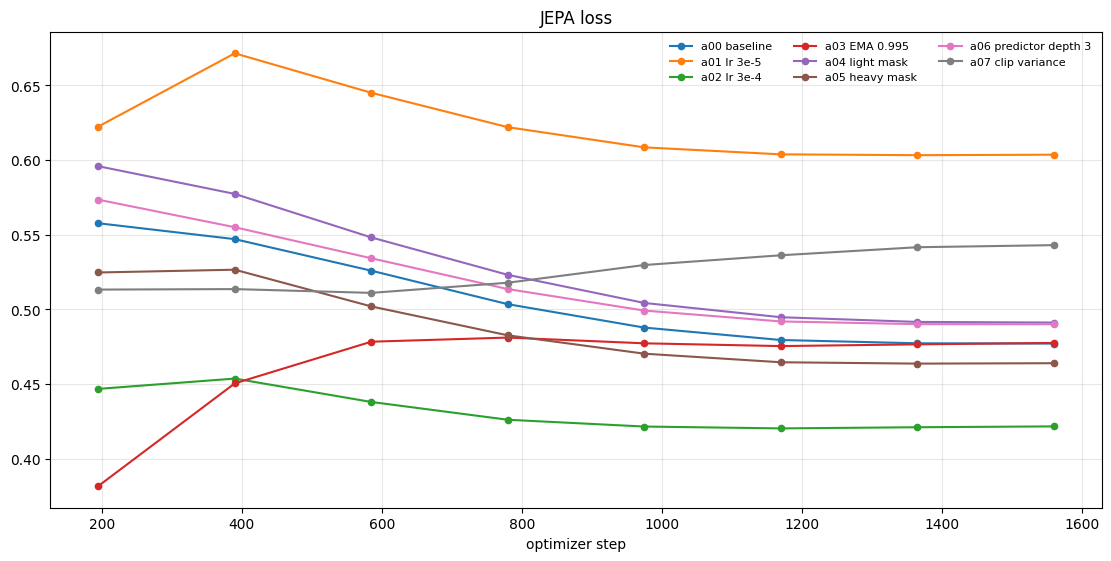

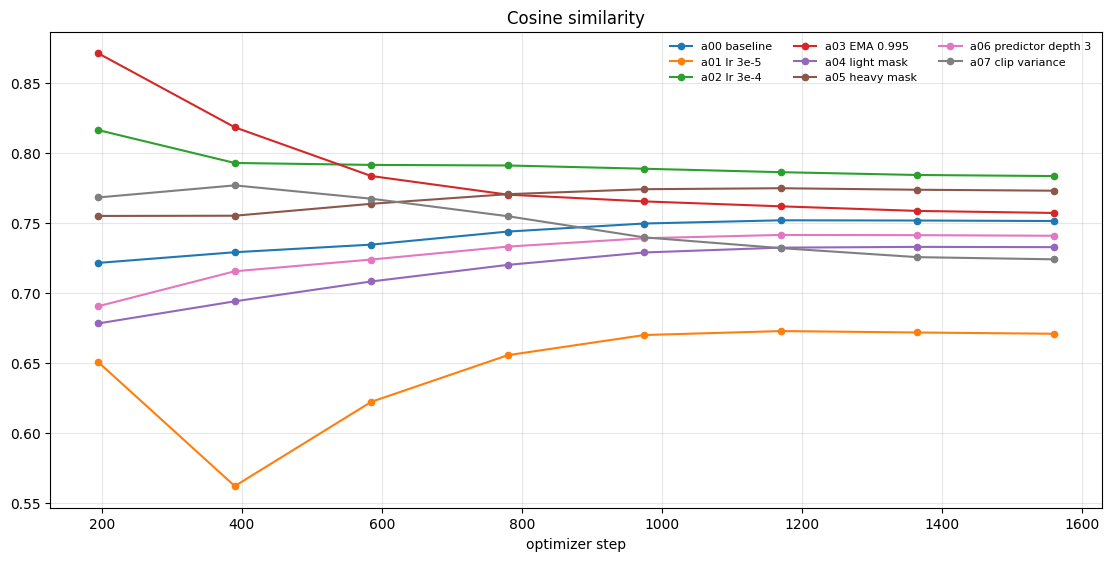

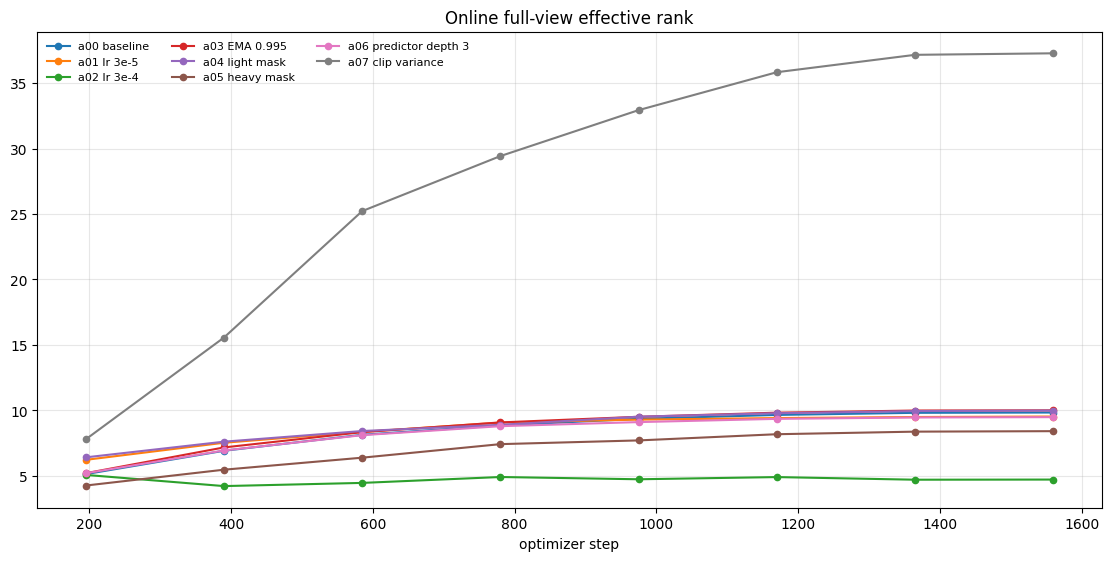

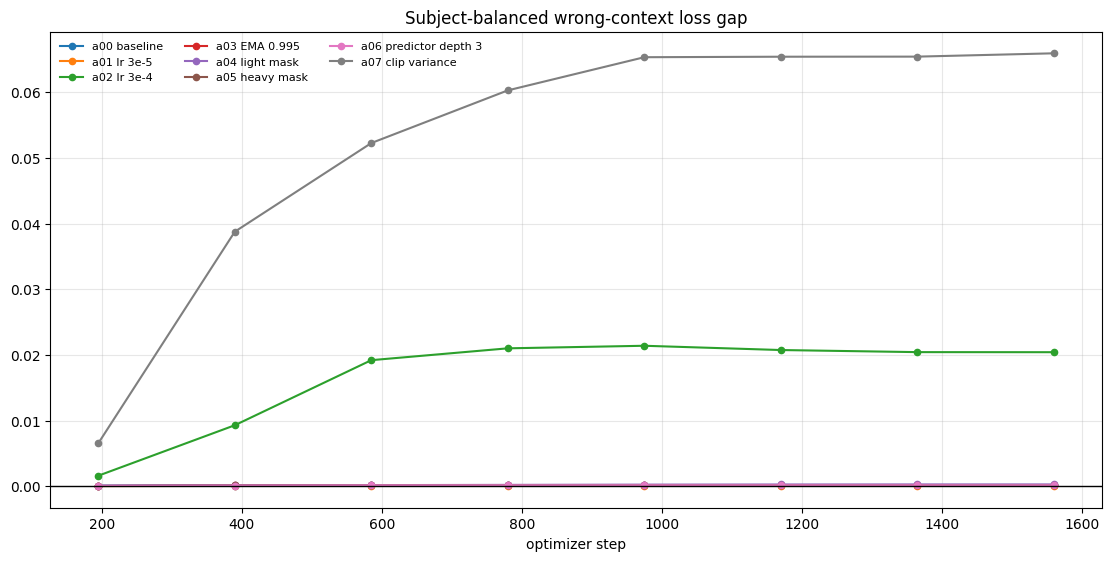

/Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-health/writeup-7-27-jepa-loss.png
/Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-health/writeup-7-27-cosine-similarity.png
/Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-health/writeup-7-27-effective-rank.png
/Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-27-health/writeup-7-27-wrong-context-gap.png


In [6]:
colors = plt.get_cmap('tab10').colors[:len(STAGE_A_RUNS)]
run_colors = {run_id: color for (run_id, _), color in zip(STAGE_A_RUNS, colors)}


def save_health_plot(metric: str, filename: str, *, zero_line: bool = False) -> Path:
    fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
    for run_id, label in STAGE_A_RUNS:
        run_rows = health.loc[health['run_id'].eq(run_id)]
        ax.plot(
            run_rows['step'], run_rows[metric], 'o-',
            color=run_colors[run_id], linewidth=1.5, markersize=4.5, label=label,
        )
    if zero_line:
        ax.axhline(0, color='black', linewidth=1)
    ax.set_title(HEALTH_METRICS[metric])
    ax.set_xlabel('optimizer step')
    ax.xaxis.set_major_locator(MaxNLocator(8, integer=True))
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, ncol=3, fontsize=8)
    output_path = OUTPUT_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    return output_path


generated = [
    save_health_plot('loss', 'writeup-7-27-jepa-loss.png'),
    save_health_plot('cosine', 'writeup-7-27-cosine-similarity.png'),
    save_health_plot('effective_rank', 'writeup-7-27-effective-rank.png'),
    save_health_plot(
        'subject_balanced_context_shuffle_loss_gap',
        'writeup-7-27-wrong-context-gap.png', zero_line=True,
    ),
]
for path in generated:
    print(path)
